<a href="https://www.kaggle.com/code/sonawanelalitsunil/ufc-records-analysis-fight-outcome-prediction-ml?scriptVersionId=226909405" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/ufc-records-dataset/UFC_Records.csv
/kaggle/input/ufc-records-dataset/ufc-stats-website-scraper.ipynb


## Title: UFC Records Analysis & Fight Outcome Prediction

## Description:
**Explore UFC fight records to uncover trends, fighter performance metrics, and key factors influencing fight outcomes. This analysis leverages historical data to build predictive models for fight results using machine learning techniques. Whether you're a fight fan or a data enthusiast, dive into the numbers behind the octagon and predict future matchups with data-driven insights!**

In [2]:
df = pd.read_csv('/kaggle/input/ufc-records-dataset/UFC_Records.csv')

In [3]:
df.head()

,Unnamed: 0,Type of Record,Rank,Name,Total
0,0,Total Fights,1,Jim Miller,45.0
1,1,Total Fights,2,Andrei Arlovski,42.0
2,2,Total Fights,3,Donald Cerrone,38.0
3,3,Total Fights,4,Clay Guida,37.0
4,4,Total Fights,5,Rafael Dos Anjos,36.0


In [4]:
df.tail()

,Unnamed: 0,Type of Record,Rank,Name,Total
340,340,Submission Avg. per 15 Min.,6,Tim Credeur,3.29
341,341,Submission Avg. per 15 Min.,7,Jason High,3.26
342,342,Submission Avg. per 15 Min.,8,Dave Menne,3.25
343,343,Submission Avg. per 15 Min.,9,Renato Sobral,3.16
344,344,Submission Avg. per 15 Min.,10,Rousimar Palhares,3.14


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 345 entries, 0 to 344
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      345 non-null    int64  
 1   Type of Record  345 non-null    object 
 2   Rank            345 non-null    int64  
 3   Name            345 non-null    object 
 4   Total           345 non-null    float64
dtypes: float64(1), int64(2), object(2)
memory usage: 13.6+ KB


In [6]:
df.describe()

,Unnamed: 0,Rank,Total
count,345.000000,345.000000,345.000000
mean,172.000000,5.437681,164.444385
std,99.737155,2.860573,557.839128
min,0.000000,1.000000,0.000900
25%,86.000000,3.000000,1.090000
50%,172.000000,5.000000,11.000000
75%,258.000000,8.000000,23.000000
max,344.000000,10.000000,3706.000000


In [7]:
df.dtypes

Unnamed: 0          int64
Type of Record     object
Rank                int64
Name               object
Total             float64
dtype: object

In [8]:
df.isnull().sum()

Unnamed: 0        0
Type of Record    0
Rank              0
Name              0
Total             0
dtype: int64

In [9]:
df.duplicated().sum()

0

In [10]:
df.columns

Index(['Unnamed: 0', 'Type of Record', 'Rank', 'Name', 'Total'], dtype='object')

## Data visualizations

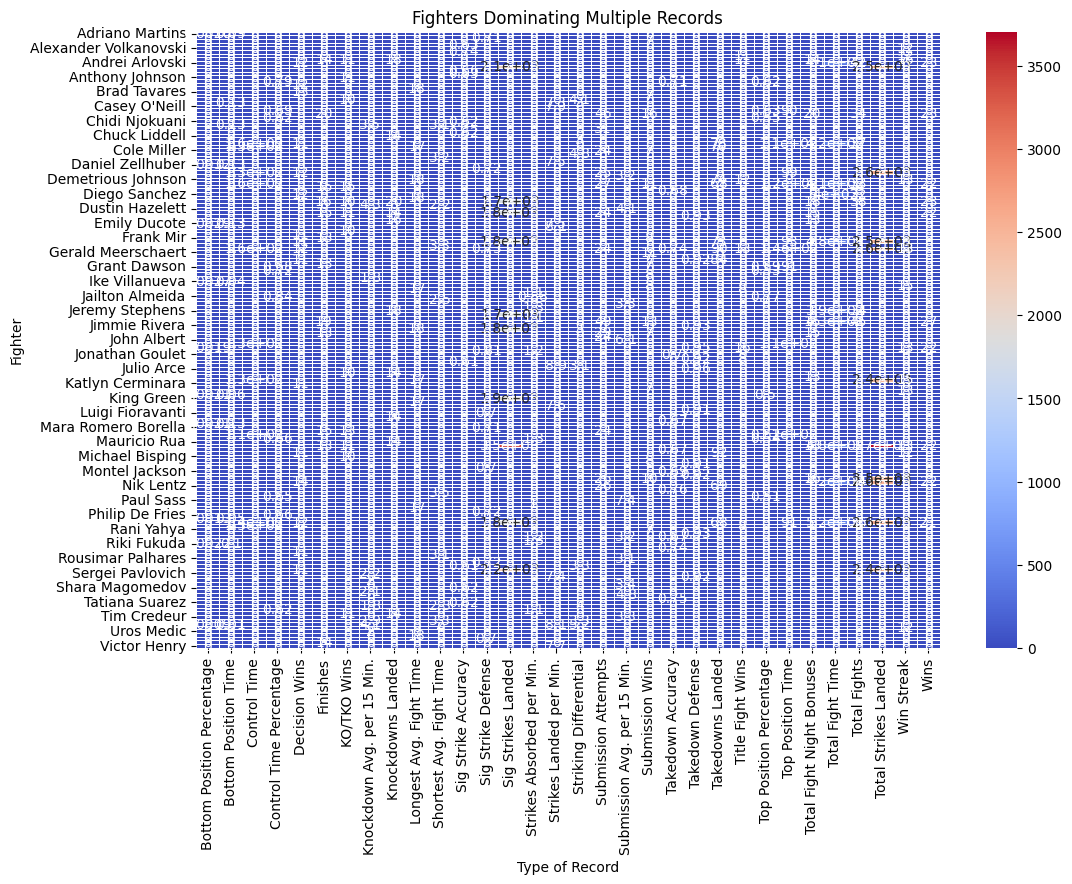

In [11]:
record_pivot = df.pivot_table(index='Name', columns='Type of Record', values='Total', aggfunc='sum', fill_value=0)
plt.figure(figsize=(12, 8))
sns.heatmap(record_pivot, cmap='coolwarm', linewidths=0.5, annot=True)
plt.title('Fighters Dominating Multiple Records')
plt.xlabel('Type of Record')
plt.ylabel('Fighter')
plt.show()

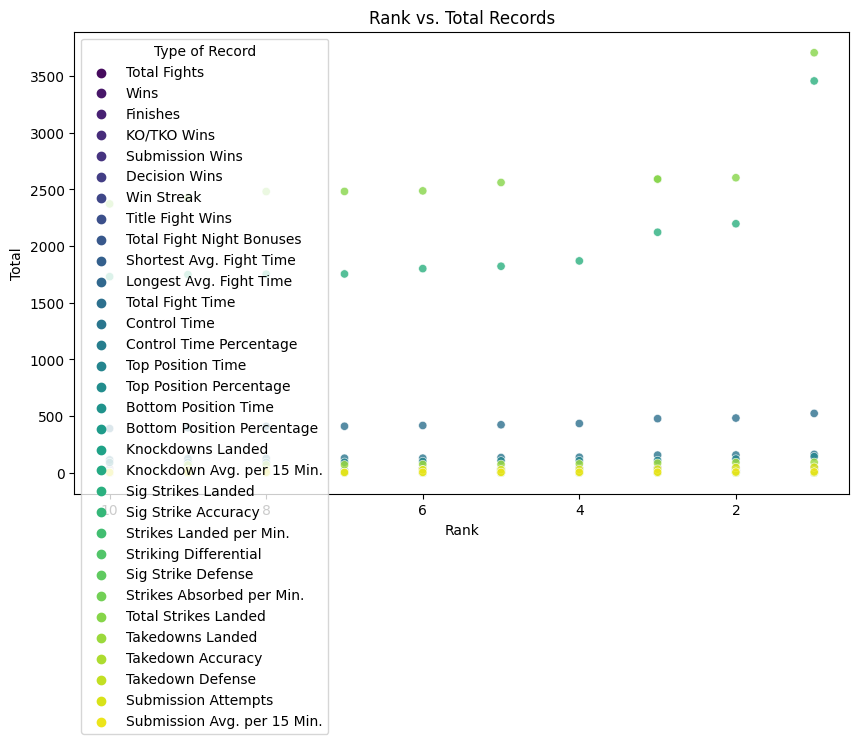

In [12]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Rank', y='Total', hue='Type of Record', data=df, palette='viridis', alpha=0.8)
plt.title('Rank vs. Total Records')
plt.xlabel('Rank')
plt.ylabel('Total')
plt.gca().invert_xaxis()  # Invert rank to show rank 1 on the left
plt.show()

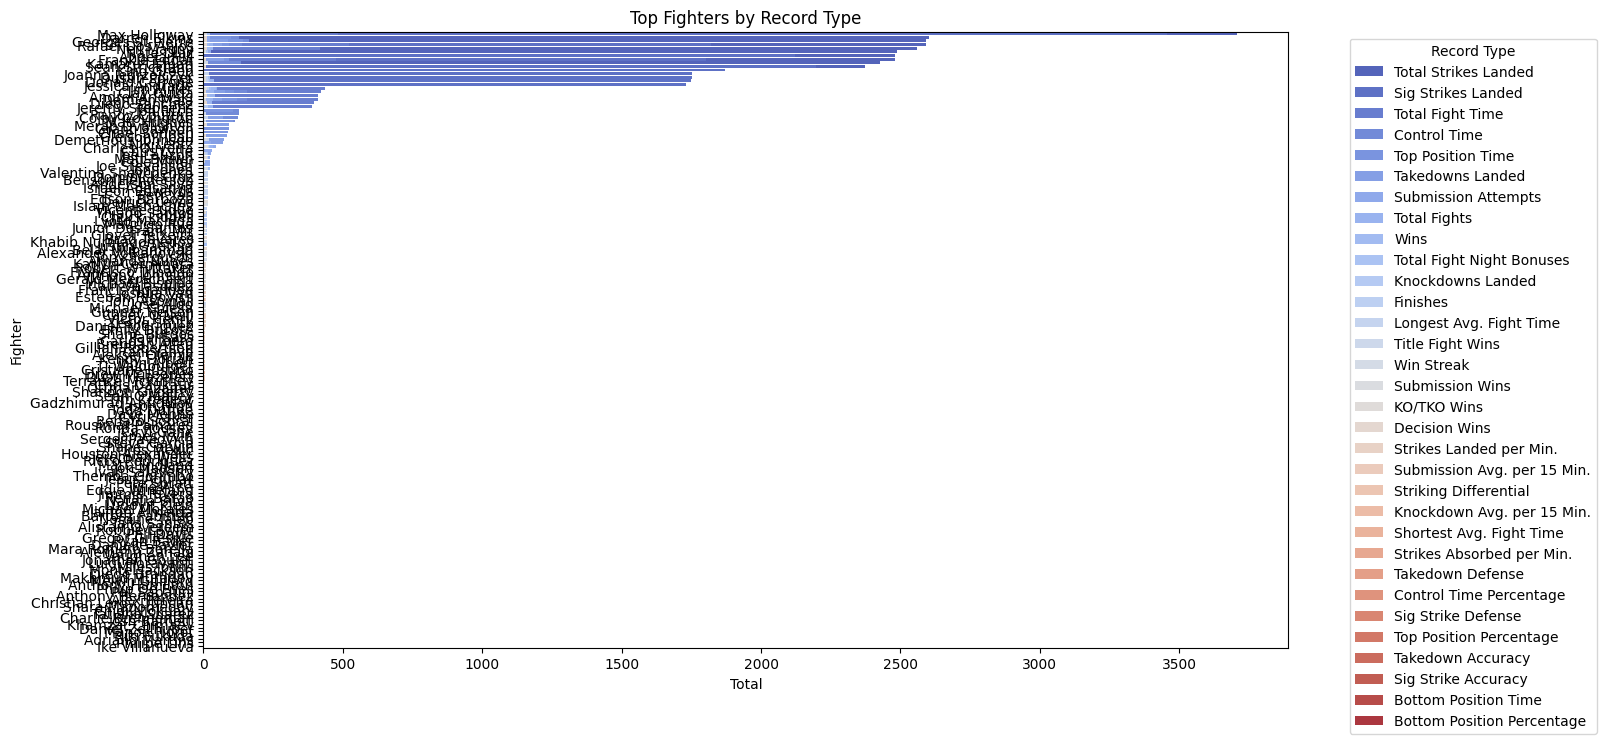

In [13]:
plt.figure(figsize=(14, 8))
df_sorted = df.sort_values(by='Total', ascending=False)
sns.barplot(y='Name', x='Total', hue='Type of Record', data=df_sorted, dodge=False, palette='coolwarm')
plt.title('Top Fighters by Record Type')
plt.xlabel('Total')
plt.ylabel('Fighter')
plt.legend(title='Record Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

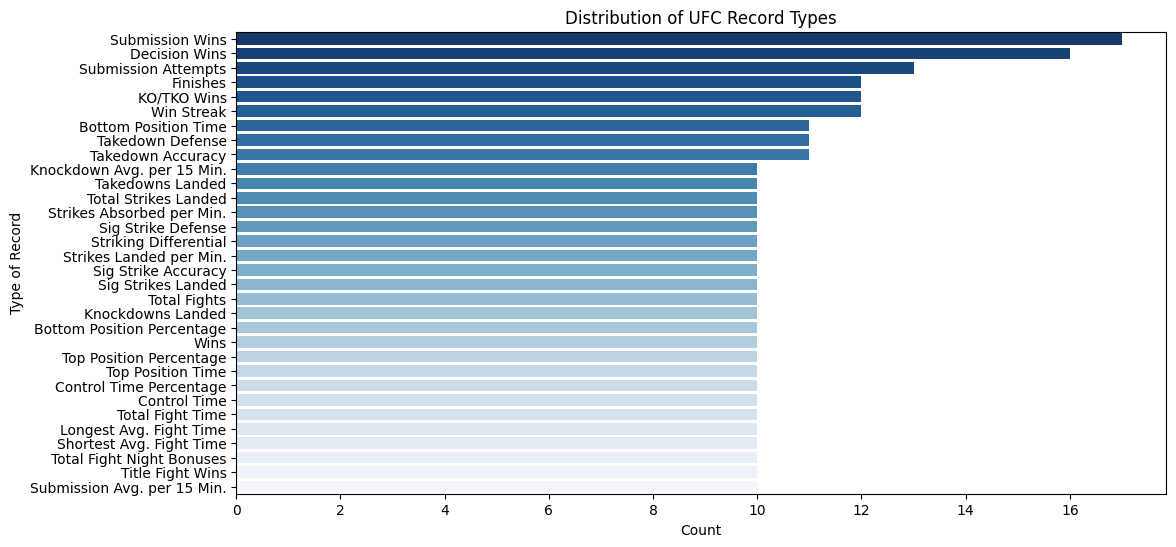

In [14]:
plt.figure(figsize=(12, 6))
sns.countplot(y='Type of Record', data=df, palette='Blues_r', order=df['Type of Record'].value_counts().index)
plt.title('Distribution of UFC Record Types')
plt.xlabel('Count')
plt.ylabel('Type of Record')
plt.show()

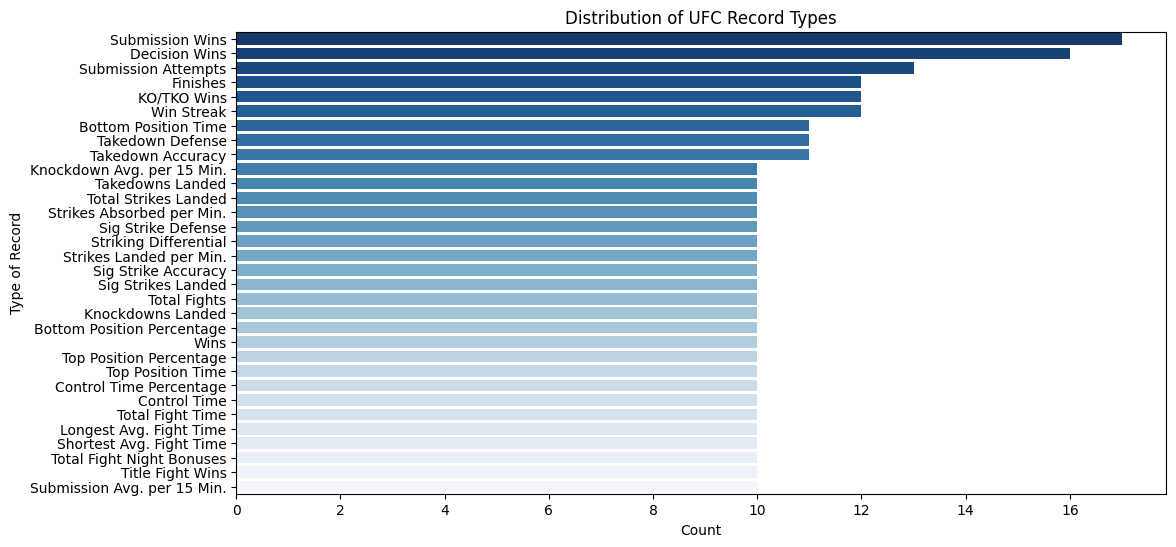

In [15]:
df = df.drop(columns=['Unnamed: 0'], errors='ignore')

# 1. Record Distribution (Bar Chart)
plt.figure(figsize=(12, 6))
sns.countplot(y='Type of Record', data=df, palette='Blues_r', order=df['Type of Record'].value_counts().index)
plt.title('Distribution of UFC Record Types')
plt.xlabel('Count')
plt.ylabel('Type of Record')
plt.show()

## Predictive modeling

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

In [17]:
df = df.drop(columns=['Unnamed: 0'], errors='ignore')  # Drop index column if unnecessary

In [18]:
df_model = pd.get_dummies(df, columns=['Type of Record'], drop_first=True)

In [19]:
features = [col for col in df_model.columns if col not in ['Rank', 'Name']]
X = df_model[features]
y = df_model['Rank']

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [21]:
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42),
    'SVR': SVR(),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42)
}

results = {}

In [22]:
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    # Multiply R² by 100 to show as percentage
    results[name] = {'MSE': mse, 'R2': r2 * 100}
    print(f"{name} - Mean Squared Error: {mse:.2f}, R^2 Score: {r2 * 100:.2f}%")


Linear Regression - Mean Squared Error: 11.82, R^2 Score: -21.36%
Decision Tree - Mean Squared Error: 3.90, R^2 Score: 59.98%
Random Forest - Mean Squared Error: 3.53, R^2 Score: 63.74%
SVR - Mean Squared Error: 9.86, R^2 Score: -1.17%
Gradient Boosting - Mean Squared Error: 6.11, R^2 Score: 37.33%


In [23]:
best_model_name = max(results, key=lambda x: results[x]['R2'])
best_model = models[best_model_name]
print(f"\nBest Model: {best_model_name}")


Best Model: Random Forest


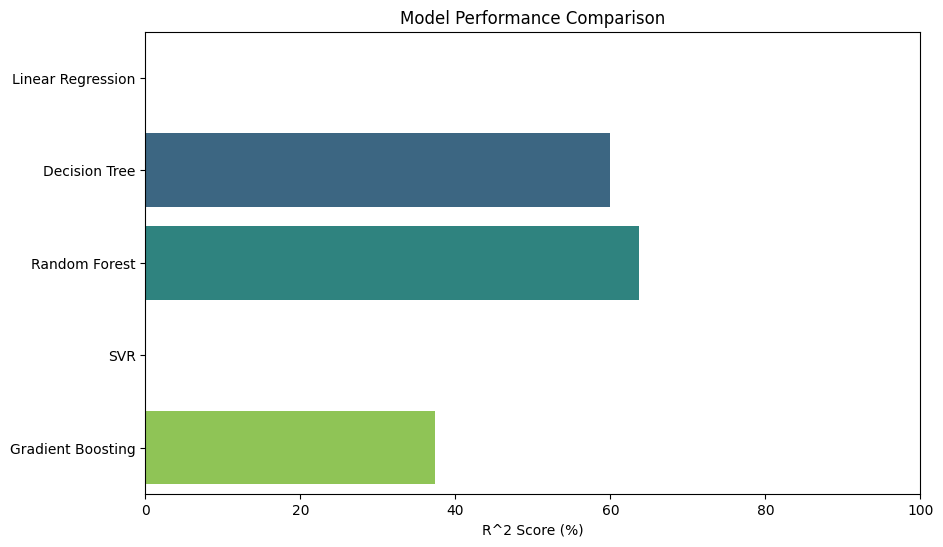

In [24]:
model_names = list(results.keys())
r2_scores = [results[m]['R2'] for m in model_names]

plt.figure(figsize=(10, 6))
sns.barplot(x=r2_scores, y=model_names, palette='viridis')
plt.xlabel('R^2 Score (%)')
plt.title('Model Performance Comparison')
plt.xlim(0, 100)  # since R² is represented as percentage
plt.show()

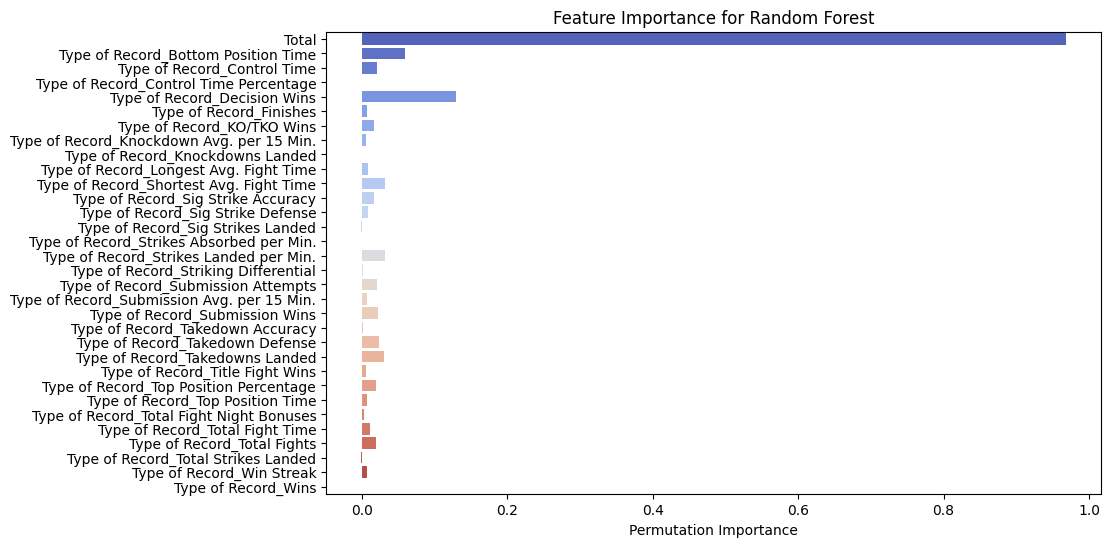

In [25]:
perm_importance = permutation_importance(best_model, X_test, y_test, n_repeats=10, random_state=42)
importances = perm_importance.importances_mean

plt.figure(figsize=(10, 6))
sns.barplot(x=importances, y=features, palette='coolwarm')
plt.xlabel('Permutation Importance')
plt.title(f'Feature Importance for {best_model_name}')
plt.show()

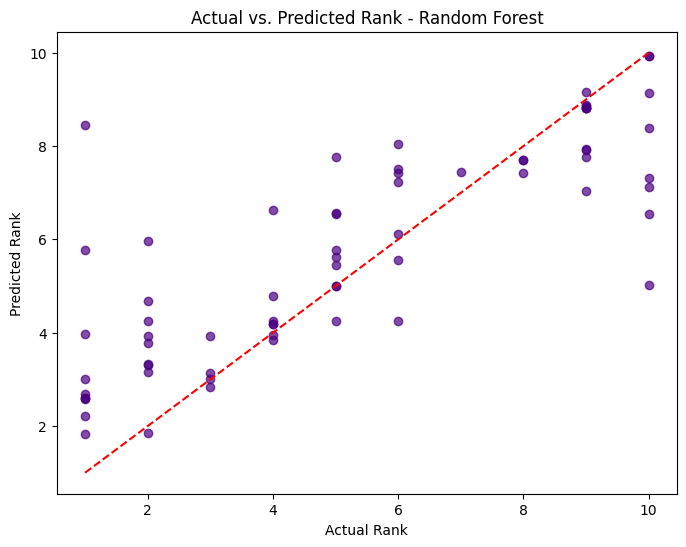

In [26]:
y_pred_best = best_model.predict(X_test)
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_best, alpha=0.7, color='indigo')
plt.xlabel('Actual Rank')
plt.ylabel('Predicted Rank')
plt.title(f'Actual vs. Predicted Rank - {best_model_name}')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()

## Thank you!!!!...upvote....!!!